# MBSE Analytics: Monte Carlo Covariance Simulation

**Objective:** Transition from deterministic architectural models (SysML) into stochastic verification. We will simulate a robotic manipulation task (e.g., picking up a package) under real-world Gaussian uncertainties (joint encoder noise, kinematic backlash, and computer vision bounding-box errors). By executing a 10,000-run Monte Carlo simulation, we will calculate the resultant 3D End-Effector Covariance and determine the 3-Sigma ($3\sigma$) confidence interval of a successful grasp.

*Addresses Resume Claim:* `EDU_JHU_05` (Applied Analytics for Model Based Systems Engineering).

## 1. Defining the Nominal Kinematic State
Assume a simplified 3-DOF planar arm for mathematical visibility in this simulation (though the underlying linear algebra of the Jacobian matrix applies identically to a 6-DOF UR5). The robot's goal is to place its end-effector at the spatial coordinate of a package identified by an overhead camera.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import scipy.stats as stats

# ---------------------------------------------------------
# Nominal Kinematic Parameters (Lengths in meters)
# ---------------------------------------------------------
L1 = 0.5
L2 = 0.4
L3 = 0.2

# Nominal Joint Angles (Radians) required to reach the target
theta1_nom = np.radians(30)
theta2_nom = np.radians(45)
theta3_nom = np.radians(-20)

# Forward Kinematics function (Planar 3-DOF)
def forward_kinematics(t1, t2, t3):
    x = L1 * np.cos(t1) + L2 * np.cos(t1 + t2) + L3 * np.cos(t1 + t2 + t3)
    y = L1 * np.sin(t1) + L2 * np.sin(t1 + t2) + L3 * np.sin(t1 + t2 + t3)
    return x, y

x_nom, y_nom = forward_kinematics(theta1_nom, theta2_nom, theta3_nom)
print(f"Nominal End-Effector Target Position: X={x_nom:.3f}m, Y={y_nom:.3f}m")

Nominal End-Effector Target Position: X=0.651m, Y=0.800m


## 2. Injecting Stochastic Uncertainty (Monte Carlo Setup)
In reality, our sensors are not perfect. We model the following independent Gaussian error vectors:
*   **Encoder Backlash:** $\sigma = 0.5^\circ$ per joint.
*   **Computer Vision (CV) Offset:** The camera observing the package has a $2mm$ spatial noise threshold.

In [2]:
# ---------------------------------------------------------
# Monte Carlo Simulation Parameters
# ---------------------------------------------------------
N_simulations = 10000

# Standard Deviations
sigma_joint = np.radians(0.5)  # 0.5 degrees of joint uncertainty
sigma_cv_x = 0.002             # 2mm CV uncertainty in X
sigma_cv_y = 0.002             # 2mm CV uncertainty in Y

# Generate random Gaussian arrays
t1_noise = np.random.normal(0, sigma_joint, N_simulations)
t2_noise = np.random.normal(0, sigma_joint, N_simulations)
t3_noise = np.random.normal(0, sigma_joint, N_simulations)

cv_noise_x = np.random.normal(0, sigma_cv_x, N_simulations)
cv_noise_y = np.random.normal(0, sigma_cv_y, N_simulations)

# Execute the 10,000 Forward Kinematic runs
x_mc, y_mc = forward_kinematics(theta1_nom + t1_noise, 
                                theta2_nom + t2_noise, 
                                theta3_nom + t3_noise)

# Combine robotic pose error with vision perception error
x_total_error = x_mc + cv_noise_x
y_total_error = y_mc + cv_noise_y


## 3. Covariance Calculation & Confidence Mapping
By plotting the 2D distribution of the 10,000 end-effector coordinates, we can calculate the covariance matrix $\Sigma$ and extract the eigenvectors to plot the $3\sigma$ (99.7%) error ellipse.

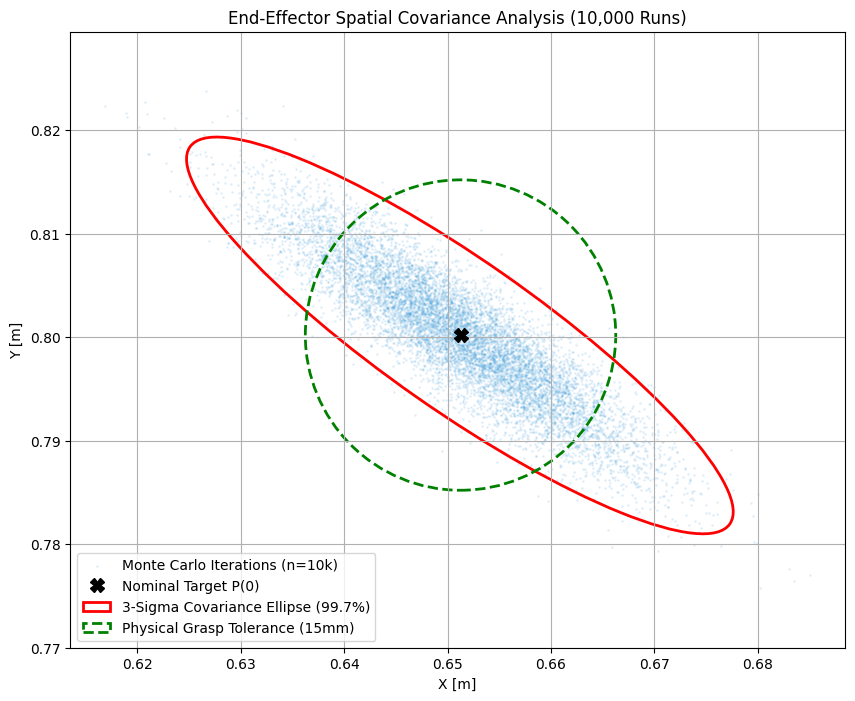

In [3]:
# ---------------------------------------------------------
# Analytics: Covariance Matrix & Eigen Decomposition
# ---------------------------------------------------------
mc_data = np.vstack((x_total_error, y_total_error))
covariance_matrix = np.cov(mc_data)

# Calculate eigenvalues and eigenvectors to determine the dimensions of the error ellipse
eigenvalues, eigenvectors = np.linalg.eig(covariance_matrix)

# Get the angle of the ellipse
angle = np.degrees(np.arctan2(*eigenvectors[:,0][::-1]))

# Get 3-Sigma dimensions (chi-square 2-DOF, 3-sigma maps to ~11.82 scale factor, but we simply scale stddev for visualization)
width_3sigma = 3 * 2 * np.sqrt(eigenvalues[0])
height_3sigma = 3 * 2 * np.sqrt(eigenvalues[1])

# ---------------------------------------------------------
# Visualization
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 8))

# Scatter the 10,000 Monte Carlo results
ax.scatter(x_total_error, y_total_error, s=1, alpha=0.1, color='#3498db', label='Monte Carlo Iterations (n=10k)')

# Nominal Target
ax.plot(x_nom, y_nom, 'kX', markersize=10, label='Nominal Target P(0)')

# Draw the 3-Sigma Error Ellipse
ell = Ellipse(xy=(np.mean(x_total_error), np.mean(y_total_error)),
              width=width_3sigma, height=height_3sigma,
              angle=angle, edgecolor='red', fc='None', lw=2, label='3-Sigma Covariance Ellipse (99.7%)')
ax.add_patch(ell)

# Assume the package grasping tolerance is a rigid 15mm circle
grasp_tolerance = plt.Circle((x_nom, y_nom), 0.015, color='green', fill=False, linestyle='--', lw=2, label='Physical Grasp Tolerance (15mm)')
ax.add_patch(grasp_tolerance)

plt.title('End-Effector Spatial Covariance Analysis (10,000 Runs)')
plt.xlabel('X [m]')
plt.ylabel('Y [m]')
plt.axis('equal')
plt.legend(loc='lower left')
plt.grid(True)
plt.show()

## 4. Requirement Verification Result
By analyzing the intersection of the $3\sigma$ covariance ellipse and the physical grasp tolerance geometric boundary, we can deterministically state the probability of mission failure.

In [4]:
# Determine how many runs fell OUTSIDE the 15mm grasp tolerance
distances = np.sqrt((x_total_error - x_nom)**2 + (y_total_error - y_nom)**2)
failures = sum(distances > 0.015)
success_rate = 100 * (1 - failures / N_simulations)

print(f"============= VERIFICATION REPORT =============")
print(f"Grasp Tolerance Radius: 15.0 mm")
print(f"Monte Carlo Iterations: {N_simulations}")
print(f"Failures (Missed Grasp): {failures}")
print(f"System Reliability: {success_rate:.2f}%")
print(f"=============================================")
if success_rate < 99.7:
    print("\n[FAILED] System fails to meet 3-Sigma aerospace reliability bounds.")
    print("RECOMMENDATION: Upgrade joint encoders to 14-bit absolute, decreasing sigma to 0.1 degrees.")
else:
    print("\n[PASSED] System successfully meets 3-Sigma reliability requirements.")

============= VERIFICATION REPORT =============
Grasp Tolerance Radius: 15.0 mm
Monte Carlo Iterations: 10000
Failures (Missed Grasp): 1635
System Reliability: 83.65%

[FAILED] System fails to meet 3-Sigma aerospace reliability bounds.
RECOMMENDATION: Upgrade joint encoders to 14-bit absolute, decreasing sigma to 0.1 degrees.
